In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn

In [ ]:
try:
    df = pd.read_csv("/content/Crime_Data_from_2020_to_2024.csv")
except FileNotFoundError:
    print("Error: The CSV file was not found. Please ensure the path is correct.")
    df = pd.DataFrame() # Assign an empty DataFrame or handle as appropriate

In [ ]:
df.shape

(65849, 28)

In [ ]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,4/11/2021 0:00,11/7/2020 0:00,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 0:00,10/18/2020 0:00,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 0:00,10/30/2020 0:00,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 0:00,12/24/2020 0:00,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/3/2020 0:00,9/29/2020 0:00,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [ ]:
df = df.drop_duplicates(subset="DR_NO")

**CONVERT DATES**

In [ ]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], format='%m/%d/%Y %I:%M:%S %p')
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], format='%m/%d/%Y %I:%M:%S %p')

In [ ]:
def convert_time(x):
  try:
    x = int(x)
    return f"{x//100:02d}:{x%100:02d}"
  except:
    return x
df['TIME OCC'] = df['TIME OCC'].apply(convert_time)
df['TIME OCC'] = pd.to_datetime(df['TIME OCC'], format='%H:%M').dt.time

In [ ]:
df['Vict Age'] = df['Vict Age'].replace(0, np.nan)
df['Vict Age'] = df['Vict Age'].fillna(df['Vict Age'].median())

df['Weapon Desc'] = df['Weapon Desc'].fillna("Unknown")
df['Vict Sex'] = df['Vict Sex'].fillna("U")

**FEATURE ENGINEERING**

In [ ]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['Year'] =  df['DATE OCC'].dt.year
df['Month'] = df['DATE OCC'].dt.month
df['Day'] =  df['DATE OCC'].dt.day_name()

# extract hour
df['Hour'] = pd.to_datetime(df['TIME OCC'], format='%H%M%S', errors='coerce').dt.hour

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57691 entries, 0 to 57690
Data columns (total 32 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DR_NO           57691 non-null  int64         
 1   Date Rptd       57691 non-null  object        
 2   DATE OCC        57691 non-null  datetime64[ns]
 3   TIME OCC        57691 non-null  int64         
 4   AREA            57691 non-null  int64         
 5   AREA NAME       57691 non-null  object        
 6   Rpt Dist No     57691 non-null  int64         
 7   Part 1-2        57691 non-null  int64         
 8   Crm Cd          57691 non-null  int64         
 9   Crm Cd Desc     57691 non-null  object        
 10  Mocodes         49362 non-null  object        
 11  Vict Age        57691 non-null  float64       
 12  Vict Sex        57691 non-null  object        
 13  Vict Descent    49880 non-null  object        
 14  Premis Cd       57689 non-null  float64       
 15  Pr

In [ ]:
df.describe()

,DR_NO,DATE OCC,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON,Year,Month,Hour
count,5.769100e+04,57691,57691.000000,57691.000000,57691.000000,57691.000000,57691.000000,57691.000000,57689.000000,19908.000000,57690.000000,4748.000000,183.000000,4.0,57690.000000,57690.000000,57691.0,57691.000000,55256.000000
mean,2.030014e+08,2020-07-05 05:51:13.207259136,1347.112323,16.430188,1689.765596,1.425266,507.140750,39.094625,302.074174,365.108147,506.849315,944.874895,987.453552,998.0,33.961123,-117.879548,2020.0,6.642076,13.891776
min,1.903265e+08,2020-01-01 00:00:00,1.000000,1.000000,101.000000,1.000000,110.000000,-4.000000,101.000000,101.000000,110.000000,210.000000,626.000000,998.0,0.000000,-118.667600,2020.0,1.000000,1.000000
25%,2.015102e+08,2020-04-06 00:00:00,927.500000,14.000000,1488.000000,1.000000,331.000000,31.000000,102.000000,311.000000,331.000000,998.000000,998.000000,998.0,33.995700,-118.461900,2020.0,4.000000,10.000000
50%,2.018061e+08,2020-07-06 00:00:00,1425.000000,17.000000,1745.000000,1.000000,480.000000,37.000000,203.000000,400.000000,480.000000,998.000000,998.000000,998.0,34.117500,-118.392100,2020.0,7.000000,15.000000
75%,2.020104e+08,2020-10-05 00:00:00,1900.000000,19.000000,1967.000000,2.000000,626.000000,46.000000,501.000000,400.000000,626.000000,998.000000,998.000000,998.0,34.222275,-118.290300,2020.0,10.000000,19.000000
max,2.514041e+08,2020-12-31 00:00:00,2359.000000,21.000000,2198.000000,2.000000,956.000000,99.000000,958.000000,516.000000,956.000000,999.000000,998.000000,998.0,34.329300,0.000000,2020.0,12.000000,23.000000
std,4.659494e+06,NaN,645.966961,3.478736,348.656648,0.494388,207.265367,13.653884,210.777530,120.129118,207.047606,126.609528,43.833937,0.0,2.248291,7.793255,0.0,3.469847,5.948752


**EDA VISUALISATIONS**

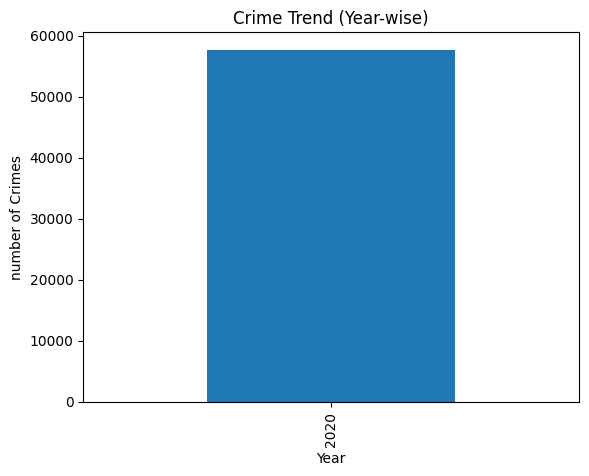

In [ ]:
year_counts = df['Year'].value_counts().sort_index()
plt.figure()
year_counts.plot(kind='bar')
plt.title("Crime Trend (Year-wise)")
plt.xlabel("Year")
plt.ylabel("number of Crimes")
plt.show()

**TOP CRIME TYPES**

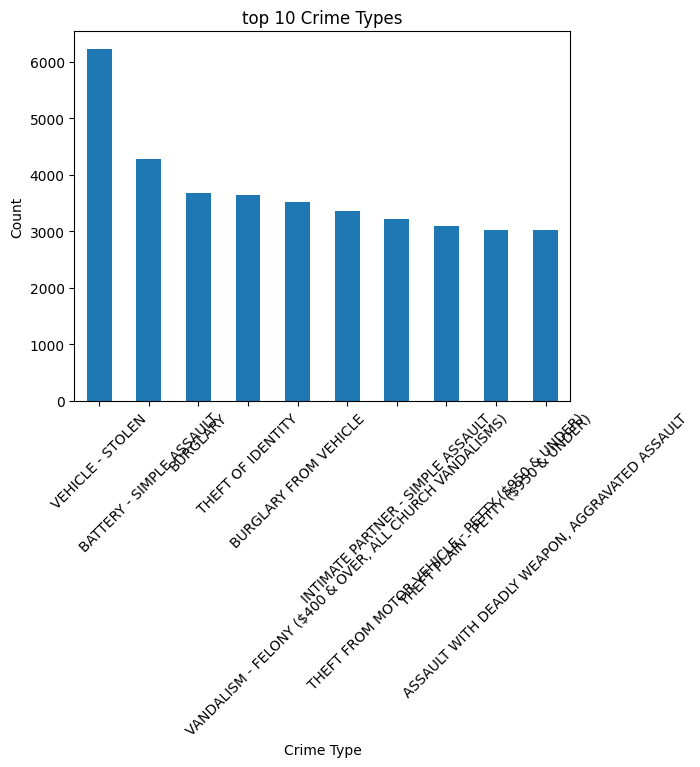

In [ ]:
top_crimes = df['Crm Cd Desc'].value_counts ().head(10)
plt.figure()
top_crimes.plot(kind='bar')
plt.title("top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()



**AREA WISE CRIME**

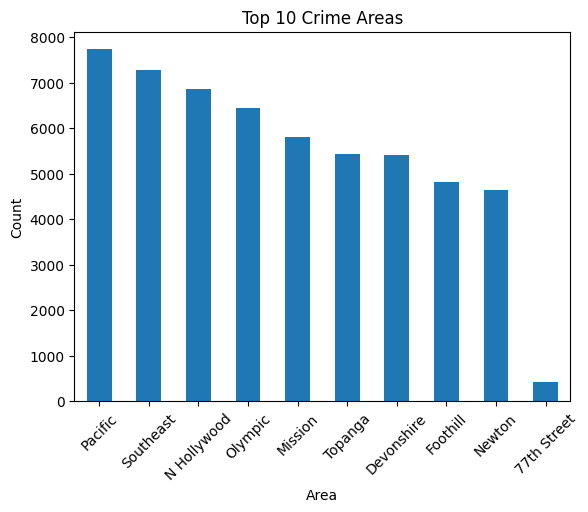

In [ ]:
area_counts = df['AREA NAME'].value_counts().head(10)
plt.figure()
area_counts.plot(kind='bar')
plt.title("Top 10 Crime Areas")
plt.xlabel("Area")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
hour_counts = df['Hour'].value_counts().sort_index()
plt.figure()
hour_counts.plot(kind='bar')
plt.title("Crimes by hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

NameError: name 'df' is not defined

**CRIMES BY DAY**

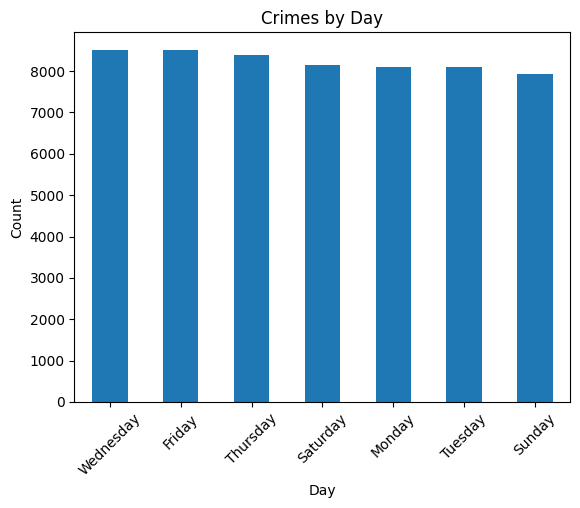

In [ ]:
day_counts = df['Day'].value_counts()
plt.figure()
day_counts.plot(kind='bar')
plt.title("Crimes by Day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

**VICTIM AGE DISTRIBUTION**

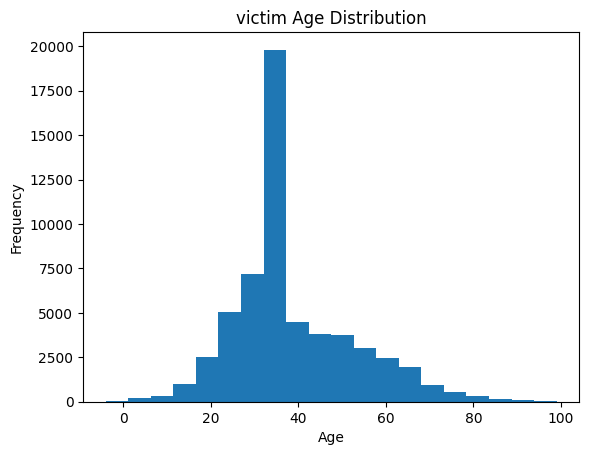

In [ ]:
plt.figure()
df['Vict Age'].plot(kind='hist', bins=20)
plt.title("victim Age Distribution")
plt.xlabel("Age")
plt.show()

**GENDER DISTRIBUTION**

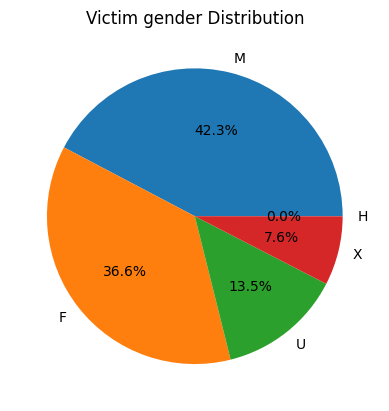

In [ ]:

gender_counts = df['Vict Sex'].value_counts()
plt.figure()
gender_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Victim gender Distribution")
plt.ylabel("")
plt.show()

**WEAPON ANALYSIS**


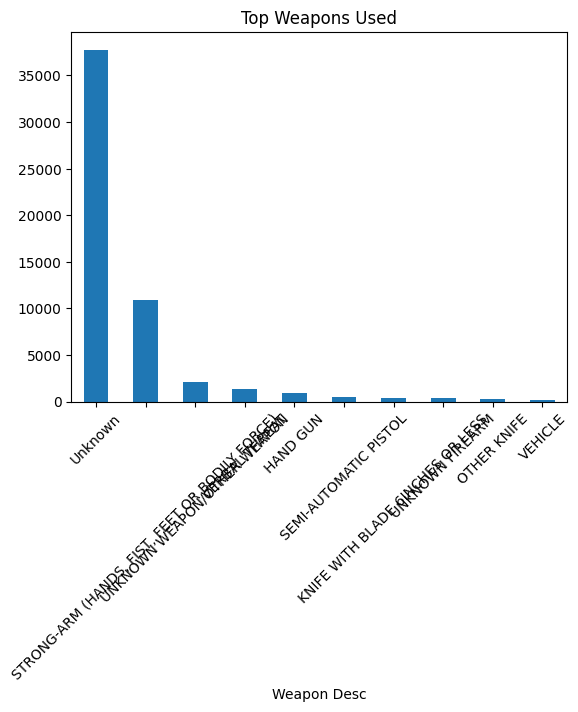

In [ ]:
weapon_counts = df['Weapon Desc'].value_counts().head(10)
plt.figure()
weapon_counts.plot(kind='bar')
plt.title("Top Weapons Used")
plt.xticks(rotation=45)
plt.show()

**PREMISES ANALYSIS**

In [ ]:
premis_counts = df['Premis Desc'].value_counts().head(10)
plt.figure()
premis_counts.plot(kind='bar')
plt.title("Top crime location")
plt.xticks(rotation=45)
plt.show()

NameError: name 'df' is not defined

**ADVANCE ANALYSIS**

**CRIMES BY YEAR & AREA**

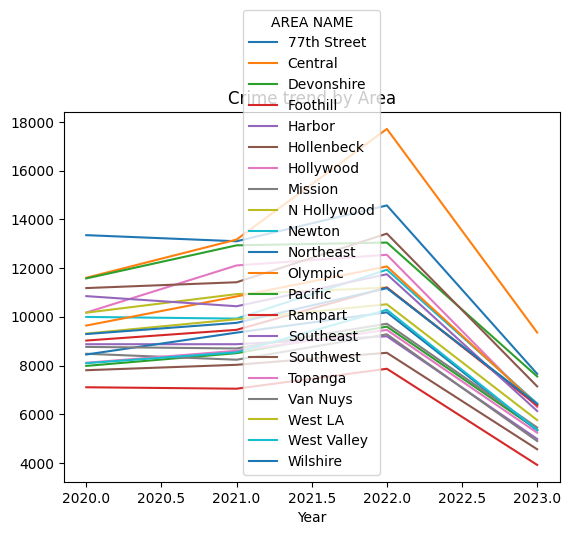

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Temporarily re-loading df to resolve NameError if kernel state was lost
# For complete analysis, ensure all preceding data loading and preprocessing cells are run.
try:
    df = pd.read_csv("/content/Crime_Data_from_2020_to_2024.csv")
except FileNotFoundError:
    print("Error: The CSV file was not found. Please ensure the path is correct.")
    df = pd.DataFrame() # Assign an empty DataFrame or handle as appropriate

df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], errors='coerce')
df['Year'] =  df['DATE OCC'].dt.year
pivot = pd.pivot_table(df,values='DR_NO', index='Year', columns='AREA NAME', aggfunc='count')

pivot.plot(kind='line')
plt.title("Crime trend by Area")
plt.show()

**PEAK CRIME HOURS**

In [ ]:
df['Hour'] = pd.to_datetime(df['TIME OCC'], format='%H%M%S', errors='coerce').dt.hour
peak_hour = df['Hour'].value_counts().idxmax()
print("Peak  Crime Hour", peak_hour)

Peak  Crime Hour 12.0


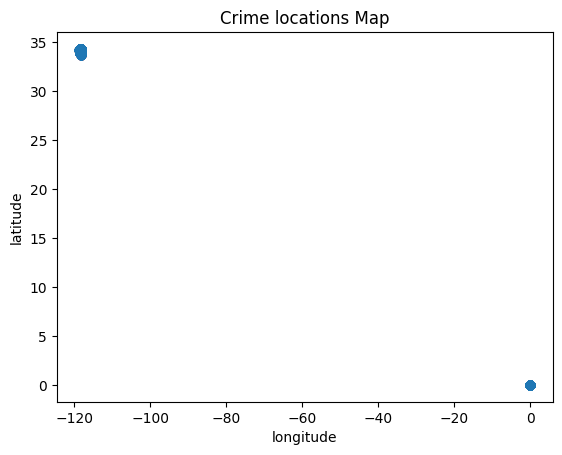

In [ ]:
plt.figure()
plt.scatter(df['LON'], df['LAT'], alpha=0.3)
plt.title("Crime locations Map")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

**SAVE CLEAN DATA**

In [ ]:
df.to_csv("clean_data.csv", index=False)